### Transformer Encoder for Sentiment Analysis: IMDB Movie Reviews
Source: https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter11_part03_transformer.ipynb

**Getting the data**

In [ ]:
!curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xf aclImdb_v1.tar.gz
!rm -r aclImdb/train/unsup

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.2M  100 80.2M    0     0  5316k      0  0:00:15  0:00:15 --:--:-- 8458k


**Preparing the data**

In [1]:
# --- CPU threading/env (must run BEFORE importing tensorflow) ---
import os

os.environ["OMP_NUM_THREADS"]           = "16"   # oneDNN/OpenMP threads per op (convs/matmuls)
os.environ["TF_NUM_INTRAOP_THREADS"]    = "16"   # TF parallelism within an op
os.environ["TF_NUM_INTEROP_THREADS"]    = "4"    # TF parallelism across ops (2–4 is sensible for 16 cores)
os.environ["TF_ENABLE_ONEDNN_OPTS"]     = "1"    # use optimized oneDNN kernels
os.environ["KMP_BLOCKTIME"]             = "0"    # return threads to pool immediately (reduces tail latency)
os.environ["KMP_AFFINITY"]              = "granularity=fine,compact,1,0"  # pack threads onto cores tightly

# Optional: try XLA JIT; can speed CPU graphs. If it regresses, set to "0".
os.environ["TF_XLA_FLAGS"]              = "--tf_xla_auto_jit=2"

In [2]:
# --- Import TF after env vars are set and apply runtime knobs for parallelism over cpus ---
import tensorflow as tf
import numpy as np
import random

# Repro (optional)
seed = 42
np.random.seed(seed); random.seed(seed); tf.random.set_seed(seed)

# Mirror thread settings explicitly at runtime
tf.config.threading.set_intra_op_parallelism_threads(16)   # match env; heavy ops use all cores
tf.config.threading.set_inter_op_parallelism_threads(4)    # keep inter-op modest to avoid oversubscription

# Enable/disable global JIT at runtime (kept True to match env; set False if you see slower steps)
tf.config.optimizer.set_jit(True)

2025-10-23 09:27:29.886580: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
# ========= Standard library (why) =========
import os            # configure threading / env vars for CPU efficiency and file paths
import math          # small utilities (e.g., compute number of patches)
import time          # simple timing around training/eval if desired

# ========= Third-party (why) =========
import numpy as np   # numerical arrays; small helpers for label processing and plotting

# Matplotlib (plots must be plain matplotlib; no seaborn; 1 chart per figure)
import matplotlib.pyplot as plt  # training curves, confusion matrix, prediction grids

# TensorFlow / Keras (core deep learning)
import tensorflow as tf                                 # framework runtime
from tensorflow import keras                            # Keras high-level API
from tensorflow.keras import layers, models, callbacks  # layers, Model, training callbacks
from tensorflow.keras import regularizers, initializers # L2 weight decay, He initialization

In [2]:
import os, pathlib, shutil, random
from tensorflow import keras
batch_size = 32
base_dir = pathlib.Path("aclImdb")
val_dir = base_dir / "val"
train_dir = base_dir / "train"
for category in ("neg", "pos"):
    os.makedirs(val_dir / category, exist_ok=True)
    files = os.listdir(train_dir / category)
    random.Random(1337).shuffle(files)
    num_val_samples = int(0.2 * len(files))
    val_files = files[-num_val_samples:]
    for fname in val_files:
        shutil.move(train_dir / category / fname,
                    val_dir / category / fname)

train_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/train", batch_size=batch_size
)
val_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/val", batch_size=batch_size
)
test_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/test", batch_size=batch_size
)
text_only_train_ds = train_ds.map(lambda x, y: x)

Found 16000 files belonging to 2 classes.
Found 9000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


**Vectorizing the data**

In [3]:
from tensorflow.keras import layers

max_length = 600
max_tokens = 20000
text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length,
)
text_vectorization.adapt(text_only_train_ds)

int_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
int_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
int_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)

2025-10-23 07:27:12.996835: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


**Transformer encoder implemented as a subclassed `Layer`**

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = keras.Sequential(
            [layers.Dense(dense_dim, activation="relu"),
             layers.Dense(embed_dim),]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()

    def call(self, inputs, mask=None):
        if mask is not None:
            mask = mask[:, tf.newaxis, :]
        attention_output = self.attention(
            inputs, inputs, attention_mask=mask)
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config

**Using the Transformer encoder for text classification**

In [4]:
vocab_size = 20000
#embed_dim = 256
embed_dim = 32
num_heads = 2
dense_dim = 32

inputs = keras.Input(shape=(None,), dtype="int64")
x = layers.Embedding(vocab_size, embed_dim)(inputs)
x = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 32)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, None, 32)       │        10,656 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,689 (2.48 MB)

 Trainable params: 650,689 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

**Training and evaluating the Transformer encoder based model**

In [5]:
callbacks = [
    keras.callbacks.ModelCheckpoint("transformer_encoder.keras",
                                    save_best_only=True)
]
model.fit(int_train_ds, validation_data=int_val_ds, epochs=20, callbacks=callbacks)
# model.fit(int_train_ds, validation_data=int_val_ds, epochs=2, callbacks=callbacks)
model = keras.models.load_model(
    "transformer_encoder.keras",
    custom_objects={"TransformerEncoder": TransformerEncoder})
print(f"Test acc: {model.evaluate(int_test_ds)[1]:.3f}")

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 100s 157ms/step - accuracy: 0.6746 - loss: 0.6128 - val_accuracy: 0.7886 - val_loss: 0.4564
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - accuracy: 0.7796 - loss: 0.4683 - val_accuracy: 0.8228 - val_loss: 0.4142
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - accuracy: 0.8035 - loss: 0.4321 - val_accuracy: 0.8372 - val_loss: 0.3737
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 150ms/step - accuracy: 0.8223 - loss: 0.4000 - val_accuracy: 0.8386 - val_loss: 0.3770
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 151ms/step - accuracy: 0.8306 - loss: 0.3828 - val_accuracy: 0.8486 - val_loss: 0.3526
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 151ms/step - accuracy: 0.8404 - loss: 0.3620 - val_accuracy: 0.8526 - val_loss: 0.3430
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.8480 - loss: 0.3445 - val_accuracy: 0.8592 - val_loss: 0.3335
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.8615 - loss: 

/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.8452 - loss: 0.3550
Test acc: 0.845


#### Using positional encoding to re-inject order information

**Implementing positional embedding as a subclassed layer**

In [19]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(
            input_dim=input_dim, output_dim=output_dim)
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=output_dim)
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):
        # length = tf.shape(inputs)[-1]
        # Use keras.backend instead of tf directly
        length = keras.backend.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        #return tf.math.not_equal(inputs, 0)
        #return tf.keras.backend.not_equal(inputs, 0)
        # Use Keras layers for masking operations
        mask = layers.Lambda(
            lambda x: tf.keras.backend.not_equal(x, 0)
        )(inputs)
        return mask
    # the below to fix an error with lambda layer while loading model:
    # Fix the PositionalEmbedding class
    # def compute_mask(self, inputs, mask=None):
    #     return keras.ops.not_equal(inputs, 0)

    def get_config(self):
        config = super().get_config()
        config.update({
            "output_dim": self.output_dim,
            "sequence_length": self.sequence_length,
            "input_dim": self.input_dim,
        })
        return config

#### Putting it all together: A text-classification Transformer

**Combining the Transformer encoder with positional embedding**

In [ ]:
vocab_size = 20000
sequence_length = 600
#embed_dim = 256
embed_dim = 32
num_heads = 2
dense_dim = 32

inputs = keras.Input(shape=(None,), dtype="int64")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(inputs)
x = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

callbacks = [
    keras.callbacks.ModelCheckpoint("full_transformer_encoder.keras",
                                    save_best_only=True)
]
#model.fit(int_train_ds, validation_data=int_val_ds, epochs=20, callbacks=callbacks)
model.fit(int_train_ds, validation_data=int_val_ds, epochs=20, callbacks=callbacks,verbose=2)
#model = keras.models.load_model(
#    "full_transformer_encoder.keras",
#    custom_objects={"TransformerEncoder": TransformerEncoder,
#                    "PositionalEmbedding": PositionalEmbedding},
#    safe_mode=False # Add this line to allow loading models with lambda layers
#)
print(f"Test acc: {model.evaluate(int_test_ds)[1]:.3f}")

/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'transformer_encoder_1' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 32)  │    659,200 │ input_layer_3[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, None)      │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, None, 32)  │     10,656 │ positional_embed… │
│ (TransformerEncode… │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ transformer_enco… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         33 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 669,889 (2.56 MB)

 Trainable params: 669,889 (2.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
625/625 - 107s - 172ms/step - accuracy: 0.7200 - loss: 0.5406 - val_accuracy: 0.8662 - val_loss: 0.3237
Epoch 2/20
625/625 - 105s - 168ms/step - accuracy: 0.8725 - loss: 0.3126 - val_accuracy: 0.8474 - val_loss: 0.3432
Epoch 3/20
625/625 - 105s - 168ms/step - accuracy: 0.9038 - loss: 0.2524 - val_accuracy: 0.8846 - val_loss: 0.2791
Epoch 4/20
625/625 - 104s - 167ms/step - accuracy: 0.9215 - loss: 0.2118 - val_accuracy: 0.8596 - val_loss: 0.3423
Epoch 5/20
625/625 - 104s - 166ms/step - accuracy: 0.9355 - loss: 0.1807 - val_accuracy: 0.8866 - val_loss: 0.2979
Epoch 6/20


In [20]:
# FOR TESTING, LOAD WEIGHTS ONLY
# Rebuild the exact same architecture with FIXED code
vocab_size = 20000
sequence_length = 600
embed_dim = 32
num_heads = 2
dense_dim = 32

inputs = keras.Input(shape=(None,), dtype="int64")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(inputs)
x = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
modelGO = keras.Model(inputs, outputs)

# Don't compile yet - just load the weights
modelGO.load_weights("full_transformer_encoder.keras")

# Now compile
modelGO.compile(optimizer="rmsprop",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])

# Test
print(f"Test acc: {modelGO.evaluate(int_test_ds)[1]:.3f}")



/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'transformer_encoder' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 58ms/step - accuracy: 0.5372 - loss: 1.0602
Test acc: 0.537


In [22]:
modelGO.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 32)  │    659,200 │ input_layer[0][0] │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, None)      │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, None, 32)  │     10,656 │ positional_embed… │
│ (TransformerEncode… │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ transformer_enco… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 669,889 (2.56 MB)

 Trainable params: 669,889 (2.56 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model = keras.models.load_model(
   "full_transformer_encoder.keras",
   custom_objects={"TransformerEncoder": TransformerEncoder,
                   "PositionalEmbedding": PositionalEmbedding
    },
   compile=False,  # Skip the Lambda issue
   safe_mode=False # Add this line to allow loading models with lambda layers
)
print(f"Test acc: {model.evaluate(int_test_ds)[1]:.3f}")

NotImplementedError: Exception encountered when calling Lambda.call().

[1mWe could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.[0m

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, None), dtype=int64, sparse=False, ragged=False, name=input_layer_3>',)
  • kwargs={'mask': 'None'}

In [11]:
!date; ls -lh

Fri Aug 30 10:23:53 AM UTC 2024
total 91M
drwxr-xr-x 5 7297 1000 4.0K Aug 30 08:48 aclImdb
-rw-r--r-- 1 root root  81M Aug 30 08:47 aclImdb_v1.tar.gz
-rw-r--r-- 1 root root 5.2M Aug 30 09:41 full_transformer_encoder.keras
drwxr-xr-x 1 root root 4.0K Aug 27 13:23 sample_data
-rw-r--r-- 1 root root 5.1M Aug 30 09:11 transformer_encoder.keras


# CNN followed by Transformer Encoder for Cifar-10 (to be completed)

## Prepare data

In [5]:
# =========================
# 1.1) Prepare Data
# =========================

from tensorflow.keras.utils import to_categorical
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

# One-hot encode the labels
y_train_encoded = to_categorical(y_train, num_classes=10)
y_valid_encoded = to_categorical(y_valid, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

# Print the shape of the encoded labels
print(y_train_encoded.shape)
print(y_valid_encoded.shape)
print(y_test.shape)
print(y_test_encoded.shape)
# Assume you already have normalized arrays:
# X_train (45000,32,32,3), y_train_encoded (45000,10)
# X_valid (5000,32,32,3),  y_valid_encoded (5000,10)
# X_test  (10000,32,32,3), y_test_encoded  (10000,10)

# Hyperparameters for input pipeline
AUTOTUNE    = tf.data.AUTOTUNE  # why: lets TF pick good parallelism for .map/.prefetch
BATCH_TRAIN = 512      # ↑ from 256 → fewer steps/epoch; Larger batches lower per-step overhead on CPU. use 256 if RAM is tight
BATCH_EVAL   = 1024     # larger eval batches speed validation/test
SHUFFLE_BUF  = 50_000   # full shuffle for CIFAR-10
# BATCH_TRAIN = 256        # why: larger batches reduce per-step overhead on CPU; tune for memory
# BATCH_EVAL  = 512        # why: even larger for eval; no gradients, so memory OK



# On-graph augmentations (GPU/CPU-friendly; avoids Python/PIL and the GIL)
augment = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),           # why: standard CIFAR augmentation improves generalization
        layers.RandomTranslation(0.1, 0.1),        # why: small shifts teach translation robustness
        layers.RandomZoom(0.1),                    # why: mild scale invariance
        layers.RandomRotation(0.05),               # why: minor rotations; CIFAR objects are not perfectly aligned
    ],
    name="augment"
)

# Wrap your arrays into efficient tf.data pipelines
# ---- NEW: cache raw arrays before augmentation (fits in RAM; avoids re-reading every epoch) ----
# Rule: cache BEFORE .map(augment) so we don't cache random transforms, only the base images. It prevents re-materializing base arrays every epoch
ds_train = (tf.data.Dataset.from_tensor_slices((X_train, y_train_encoded))
            .cache()                                           # why: build dataset from in-memory arrays # <--- NEW: keep base data in memory (~0.6 GB)
            .shuffle(SHUFFLE_BUF, reshuffle_each_iteration=True) # why: better stochasticity each epoch
            .batch(BATCH_TRAIN, drop_remainder=True) # why: static shapes help XLA/graph; stable step time
            .map(lambda x, y: (augment(x, training=True), y),# why: run augmentation inside the graph
                 num_parallel_calls=AUTOTUNE)                  # parallelize map work using many threads
            .prefetch(AUTOTUNE)) # why: overlap input prep with compute

ds_valid = (tf.data.Dataset.from_tensor_slices((X_valid, y_valid_encoded))
            .cache()                                    # why: validation uses clean images       # <--- NEW: cache val once; tiny
            .batch(BATCH_EVAL) # why: bigger batch speeds eval
            .prefetch(AUTOTUNE)) # why: overlap host/device

ds_test  = (tf.data.Dataset.from_tensor_slices((X_test, y_test_encoded))
            .cache()                                # why: test dataset for final metrics           # <--- NEW: cache test once; tiny
            .batch(BATCH_EVAL) # why: efficient evaluation
            .prefetch(AUTOTUNE)) # why: keep device fed

# ---- Optional: give tf.data its own private threadpool so it doesn't fight compute threads ----
opts = tf.data.Options()
opts.threading.private_threadpool_size = 6     # dedicate ~6 cores to input pipeline. lets augmentation/pipeline saturate independently of compute (we still have 10 cores for ops)
opts.autotune.enabled = True                   # let tf.data tune parallelism
ds_train = ds_train.with_options(opts)
ds_valid = ds_valid.with_options(opts)
ds_test  = ds_test.with_options(opts)

# Optional sanity print to confirm shapes and pipeline construction
print(ds_train)


(45000, 10)
(5000, 10)
(10000, 1)
(10000, 10)
<_OptionsDataset element_spec=(TensorSpec(shape=(512, 32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(512, 10), dtype=tf.float64, name=None))>


### CNN →Transformer architecture
Design:
* Conv stem: 2 lightweight conv blocks to denoise + extract local edges/colors.
* Patch embedding: Conv2D with kernel=stride=4 to produce 8×8=64 tokens of dimension D.
* Positional embeddings: trainable 1D embeddings added to tokens.
* Transformer encoder stack: Multi-Head Self-Attention + MLP with residuals & LayerNorm.
* Head: mean-pool tokens → Dropout → Dense softmax.

In [8]:
# Model hyperparameters
NUM_CLASSES    = 10                     # why: CIFAR-10 has 10 categories
WEIGHT_DECAY   = 1e-4                   # why: L2 regularization combats overfitting in conv/dense weights
DROPOUT_RATE   = 0.2                    # why: modest dropout; stronger regularizers hurt small datasets
PATCH_SIZE     = 4                      # why: 32/4 => 8, so 8x8=64 tokens; good trade-off for CIFAR-10
EMBED_DIM      = 128                    # why: token dimension (aka d_model); balanced for CPU/GPU and accuracy
NUM_HEADS      = 4                      # why: 4 heads * 32/key_dim ~= 128; standard factorization
MLP_RATIO      = 2                      # why: MLP hidden width = MLP_RATIO * EMBED_DIM; 2x is lean and effective
ENCODER_DEPTH  = 4                      # why: stacks of encoder blocks; tune 3–6 for speed/accuracy balance
INIT           = initializers.HeNormal()# why: stable ReLU/conv init

def conv_block(x, filters, name):
    """A small Conv-BN-ReLU block with L2 decay. Keeps spatial size with padding='same'."""
    x = layers.Conv2D(
        filters=filters, kernel_size=3, strides=1, padding="same", use_bias=False,
        kernel_initializer=INIT, kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name=f"{name}_conv"
    )(x)  # what: 3x3 conv; why: extract local edges/textures cheaply
    x = layers.BatchNormalization(name=f"{name}_bn")(x)  # what: BN; why: stabilize activations
    x = layers.ReLU(name=f"{name}_relu")(x)              # what: nonlinearity; why: expressive power
    return x                                             # return feature map with same HxW

def transformer_encoder(x, name):
    """One Transformer encoder block: LN → MHSA → Dropout → Residual → LN → MLP → Dropout → Residual."""
    # LayerNorm before attention (Pre-Norm); helps optimization on small batches
    x_norm1 = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(x)  # what: normalize tokens; why: stable training
    attn_out = layers.MultiHeadAttention(
        num_heads=NUM_HEADS, key_dim=EMBED_DIM // NUM_HEADS, dropout=DROPOUT_RATE,
        name=f"{name}_mhsa"
    )(x_norm1, x_norm1)  # what: self-attention over tokens; why: capture global context
    attn_out = layers.Dropout(DROPOUT_RATE, name=f"{name}_attn_drop")(attn_out)  # what: dropout; why: regularize attention
    x = layers.Add(name=f"{name}_attn_res")([x, attn_out])  # what: residual add; why: preserve gradients

    # MLP block with expansion and GELU nonlinearity
    x_norm2 = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x)  # what/why: stabilize MLP inputs
    mlp_hidden = layers.Dense(
        units=EMBED_DIM * MLP_RATIO, activation="gelu",
        kernel_initializer=INIT, kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name=f"{name}_mlp_dense1"
    )(x_norm2)  # what: expand channel; why: token-wise feature mixing
    mlp_hidden = layers.Dropout(DROPOUT_RATE, name=f"{name}_mlp_drop")(mlp_hidden)  # what/why: regularize
    mlp_out = layers.Dense(
        units=EMBED_DIM,
        kernel_initializer=INIT, kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name=f"{name}_mlp_dense2"
    )(mlp_hidden)  # what: project back to EMBED_DIM; why: residual shape match
    x = layers.Add(name=f"{name}_mlp_res")([x, mlp_out])  # what/why: residual learning
    return x  # output has same (B, Tokens, EMBED_DIM)

def build_cnn_transformer(input_shape=(32,32,3)):
    """CNN stem → patch embedding → positional encoding → N×Transformer → pooled head."""
    inputs = layers.Input(shape=input_shape, name="inputs")  # what: image input; why: CIFAR-10 size

    # ---- CNN stem: 2 lightweight blocks to denoise & enrich local features ----
    x = conv_block(inputs, filters=32, name="stem1")         # what: 32-chan local features; why: edges/colors
    x = conv_block(x,      filters=64, name="stem2")         # what: widen channels; why: richer local patterns

    # ---- Patch embedding via Conv2D with kernel=stride=PATCH_SIZE ----
    x = layers.Conv2D(
        filters=EMBED_DIM, kernel_size=PATCH_SIZE, strides=PATCH_SIZE, padding="valid",
        use_bias=False, kernel_initializer=INIT, kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name="patch_embed"
    )(x)  # what: 32x32 -> 8x8 tokens; each token has EMBED_DIM channels

    # ---- Flatten spatial tokens to sequence (B, H, W, C) -> (B, Tokens, C) ----
    H, W = (input_shape[0] // PATCH_SIZE), (input_shape[1] // PATCH_SIZE)  # what: 8,8 for 32/4
    num_tokens = H * W                                                     # what: 64 tokens
    x = layers.Reshape((num_tokens, EMBED_DIM), name="tokens")(x)          # why: Transform to [B, T, D] for attention

    # ---- Positional embeddings (trainable) added to tokens ----
    pos_embed = layers.Embedding(
        input_dim=num_tokens, output_dim=EMBED_DIM,
        embeddings_initializer="zeros", name="pos_embed"
    )(tf.range(start=0, limit=num_tokens, delta=1))      # what: [T, D] learnable offsets per position
    pos_embed = tf.expand_dims(pos_embed, axis=0)          # <-- add this line: (1, T, D)
    x = layers.Add(name="add_pos")([x, pos_embed])         # now (B,T,D) + (1,T,D) broadcasts correctly # why: inject order info absent in self-attention

    # ---- Transformer encoder stack ----
    for i in range(ENCODER_DEPTH):                       # what: repeat blocks; why: deeper global mixing
        x = transformer_encoder(x, name=f"enc{i+1}")     # why: each block adds capacity

    # ---- Classification head: mean-pool tokens -> dropout -> dense softmax ----
    x = layers.LayerNormalization(epsilon=1e-6, name="pre_head_ln")(x)  # what: normalize before pooling; why: stable stats
    x = layers.GlobalAveragePooling1D(name="token_pool")(x)             # what: mean over tokens; why: ViT-style head
    x = layers.Dropout(DROPOUT_RATE, name="head_drop")(x)               # what/why: regularize final features
    outputs = layers.Dense(
        NUM_CLASSES, activation="softmax",
        kernel_initializer=INIT, kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name="predictions"
    )(x)  # what: per-class probabilities; why: categorical cross-entropy target

    # ---- Build & compile model ----
    model = models.Model(inputs, outputs, name="CIFAR10_CNN_Transformer")  # what: Keras Model object

    # Optimizer: Adam works well; start LR=1e-3; ReduceLROnPlateau will tune it
    optimizer = keras.optimizers.Adam(learning_rate=1e-3)  # why: robust default for this size

    # Compile with one-hot loss and accuracy metric
    model.compile(
        optimizer=optimizer,                                 # what: trainable update rule
        loss="categorical_crossentropy",                     # why: multi-class one-hot labels
        metrics=["accuracy"]                                 # why: human-readable performance
    )
    return model


### Callbacks
checkpoint, early stop, LR schedule, CSV log\
Uses: callbacks

In [30]:
# Save the best (by validation accuracy); full model saved for hassle-free reload
ckpt = callbacks.ModelCheckpoint(
    filepath="cifar10_cnn_transformer.keras",  # what: file path; why: reload complete model later
    monitor="val_accuracy",                    # why: track generalization quality
    mode="max",                                # why: higher is better
    save_best_only=True,                       # why: keep smallest best model on disk
    verbose=1                                  # why: visibility when improvement happens
)

# Stop when val accuracy stalls; restore best weights to avoid overfitting tail
early = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=10, min_delta=0.001,
    restore_best_weights=True, verbose=1
)  # why: saves compute and prevents degradation

# Reduce LR on plateaus to explore finer minima
reduce = callbacks.ReduceLROnPlateau(
    monitor="val_accuracy", factor=0.5, patience=4, min_lr=1e-6, verbose=1
)  # why: automatic LR tuning lowers step size when progress stalls

# Keep a CSV of per-epoch metrics for later analysis/plots
csvlog = callbacks.CSVLogger("cifar10_cnn_transformer_log.csv", append=False)

CALLBACKS = [ckpt, early, reduce, csvlog]  # what: bundle for fit(); why: cleanliness


### Build, Train, Reload Best, Evaluate
Q1. Why a CNN stem before the Transformer?\
A1. CIFAR-10 images (32×32) are tiny; a shallow CNN denoises and extracts local edges/colors cheaply, letting the Transformer focus on global relations. This typically converges faster and better than a pure ViT at this scale.


Q2. Why PATCH_SIZE=4 and 64 tokens?\
A2. 32/4=8 per side → 64 tokens. This is a sweet spot: enough tokens for expressivity, yet small enough to keep attention quadratic cost light on CPU/GPU.


Q3. Why positional embeddings with Embedding(T, D)?\
A3. Self-attention is permutation-invariant; learnable positional embeddings inject order/position, which improves accuracy on images where spatial layout matters.


Q4. Why LayerNorm (pre-norm) and residuals?\
A4. Pre-norm stabilizes gradients with small batches. Residuals maintain signal flow, enabling deeper stacks (4–6 encoders) without vanishing gradients.


Q5. Why L2 (WEIGHT_DECAY) and Dropout?\
A5. CIFAR-10 is small; models overfit easily. L2 regularizes weights; Dropout regularizes activations. Both improve generalization without heavy augmentations.


Q6. Why ReduceLROnPlateau instead of a fixed schedule?\
A6. It’s robust when you don’t want to hand-tune warmups or cosine cycles. When val accuracy stalls, halving LR often unlocks the next accuracy bump.


Q7. How to speed up further on CPU?\
A7. Increase BATCH_TRAIN if memory allows; ensure TF_NUM_INTRAOP_THREADS matches core quota; or switch to a GPU queue — attention scales well on GPUs.


Q8. What would you try next if accuracy plateaus?\
A8. (i) Increase ENCODER_DEPTH to 6; (ii) set MLP_RATIO=3; (iii) add label smoothing (loss=CategoricalCrossentropy(label_smoothing=0.05)); (iv) adopt cosine decay LR; (v) strengthen augmentation (Cutout, RandAugment).

In [ ]:
# Build the model
model = build_cnn_transformer(input_shape=(32,32,3))  # what: instantiate architecture; why: ready to train
model.summary()                                        # why: inspect parameter count and shapes

# Train the model; on CPU expect ~seconds-per-epoch; GPU will be much faster
history = model.fit(
    ds_train,                           # what: augmented training pipeline
    validation_data=ds_valid,           # why: monitor generalization each epoch
    epochs=200,                         # what: upper bound; why: EarlyStopping will cut earlier
    callbacks=CALLBACKS,                # what: checkpoint, early stop, LR schedule, CSV log
    verbose=2                           # why: compact output (good over SSH)
)

# Reload the best model from disk to be explicit we use the best checkpoint
model = keras.models.load_model("cifar10_cnn_transformer.keras")  # why: ensure best weights/optimizer are loaded

# Final evaluation on the test set
test_loss, test_acc = model.evaluate(ds_test, verbose=2)  # what: compute generalization metrics
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")  # why: clear final report


Model: "CIFAR10_CNN_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer) │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_conv (Conv2D) │ (None, 32, 32,    │        864 │ inputs[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_bn            │ (None, 32, 32,    │        128 │ stem1_conv[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_relu (ReLU)   │ (None, 32, 32,    │          0 │ stem1_bn[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_conv (Conv2D) │ (None, 32, 32,    │     18,432 │ stem1_relu[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_bn            │ (None, 32, 32,    │        256 │ stem2_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_relu (ReLU)   │ (None, 32, 32,    │          0 │ stem2_bn[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_embed         │ (None, 8, 8, 128) │    131,072 │ stem2_relu[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tokens (Reshape)    │ (None, 64, 128)   │          0 │ patch_embed[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_pos (Add)       │ (1, 64, 128)      │          0 │ tokens[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_ln1            │ (1, 64, 128)      │        256 │ add_pos[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_mhsa           │ (1, 64, 128)      │     66,048 │ enc1_ln1[0][0],   │
│ (MultiHeadAttentio… │                   │            │ enc1_ln1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_attn_drop      │ (1, 64, 128)      │          0 │ enc1_mhsa[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_attn_res (Add) │ (1, 64, 128)      │          0 │ add_pos[0][0],    │
│                     │                   │            │ enc1_attn_drop[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_ln2            │ (1, 64, 128)      │        256 │ enc1_attn_res[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_mlp_dense1     │ (1, 64, 256)      │     33,024 │ enc1_ln2[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_mlp_drop       │ (1, 64, 256)      │          0 │ enc1_mlp_dense1[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_mlp_dense2     │ (1, 64, 128)      │     32,896 │ enc1_mlp_drop[0]

 Total params: 682,218 (2.60 MB)

 Trainable params: 682,026 (2.60 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/200

Epoch 1: val_accuracy improved from None to 0.38520, saving model to cifar10_cnn_transformer.keras
175/175 - 170s - 969ms/step - accuracy: 0.2959 - loss: 2.2374 - val_accuracy: 0.3852 - val_loss: 1.9897 - learning_rate: 1.0000e-03
Epoch 2/200

Epoch 2: val_accuracy improved from 0.38520 to 0.45100, saving model to cifar10_cnn_transformer.keras
175/175 - 162s - 927ms/step - accuracy: 0.4424 - loss: 1.8252 - val_accuracy: 0.4510 - val_loss: 1.8613 - learning_rate: 1.0000e-03
Epoch 3/200

Epoch 3: val_accuracy improved from 0.45100 to 0.51920, saving model to cifar10_cnn_transformer.keras
175/175 - 164s - 937ms/step - accuracy: 0.5110 - loss: 1.6314 - val_accuracy: 0.5192 - val_loss: 1.5938 - learning_rate: 1.0000e-03
Epoch 4/200

Epoch 4: val_accuracy did not improve from 0.51920
175/175 - 165s - 941ms/step - accuracy: 0.5498 - loss: 1.5103 - val_accuracy: 0.4972 - val_loss: 1.6381 - learning_rate: 1.0000e-03
Epoch 5/200

Epoch 5: val_accuracy improved from 0.51920 to 0.5302

### Resume training frmo last checkpoint and continue training

In [6]:
from tensorflow import keras
from tensorflow.keras import callbacks

# Load best model so far (keeps architecture, weights, optimizer state)
model = keras.models.load_model("cifar10_cnn_transformer.keras")

# Evaluate once to confirm baseline after restart (optional but recommended)
val_loss0, val_acc0 = model.evaluate(ds_valid, verbose=2)
print(f"[Resume] Baseline val_acc={val_acc0:.4f} | val_loss={val_loss0:.4f}")

# Use a NEW checkpoint filename to avoid overwriting your earlier best
ckpt = callbacks.ModelCheckpoint(
    "cifar10_cnn_transformer_resume.keras",
    monitor="val_accuracy", mode="max", save_best_only=True, verbose=1
)
early = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=10, min_delta=0.001, restore_best_weights=True, verbose=1
)
reduce = callbacks.ReduceLROnPlateau(
    monitor="val_accuracy", factor=0.5, patience=4, min_lr=1e-6, verbose=1
)
csv = callbacks.CSVLogger("cifar10_cnn_transformer_resume_log.csv", append=False)

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=200,                 # upper bound; EarlyStopping will stop earlier
    callbacks=[ckpt, early, reduce, csv],
    verbose=2
)

# Reload the best from this session explicitly
model = keras.models.load_model("cifar10_cnn_transformer_resume.keras")
print(f"Test acc: {model.evaluate(ds_test, verbose=2)[1]:.4f}")

5/5 - 3s - 575ms/step - accuracy: 0.7102 - loss: 0.9792
[Resume] Baseline val_acc=0.7102 | val_loss=0.9792
Epoch 1/200

Epoch 1: val_accuracy improved from None to 0.66700, saving model to cifar10_cnn_transformer_resume.keras
87/87 - 83s - 949ms/step - accuracy: 0.7464 - loss: 0.8616 - val_accuracy: 0.6670 - val_loss: 1.1109 - learning_rate: 1.0000e-03
Epoch 2/200

Epoch 2: val_accuracy improved from 0.66700 to 0.67340, saving model to cifar10_cnn_transformer_resume.keras
87/87 - 82s - 939ms/step - accuracy: 0.7525 - loss: 0.8334 - val_accuracy: 0.6734 - val_loss: 1.1261 - learning_rate: 1.0000e-03
Epoch 3/200

Epoch 3: val_accuracy improved from 0.67340 to 0.69380, saving model to cifar10_cnn_transformer_resume.keras
87/87 - 82s - 939ms/step - accuracy: 0.7556 - loss: 0.8280 - val_accuracy: 0.6938 - val_loss: 1.0320 - learning_rate: 1.0000e-03
Epoch 4/200

Epoch 4: val_accuracy improved from 0.69380 to 0.70480, saving model to cifar10_cnn_transformer_resume.keras
87/87 - 81s - 936ms/s

### Visualisations (curves, confusion matrix, sample predictions)

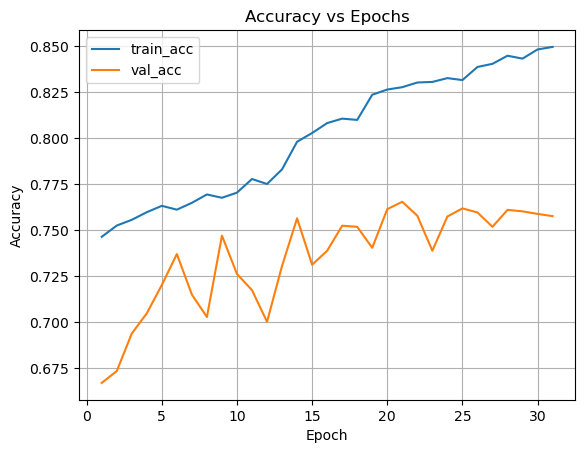

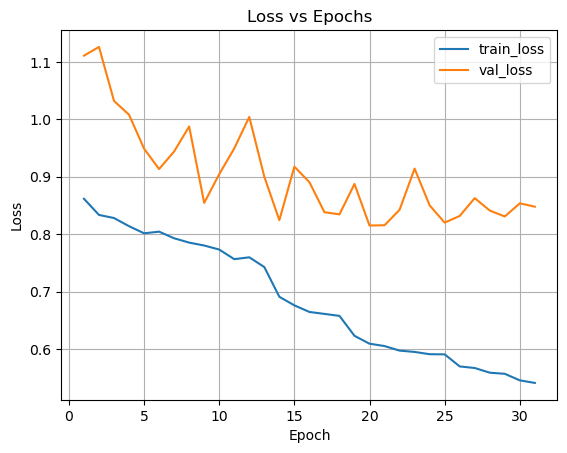

2025-10-23 10:26:06.869086: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


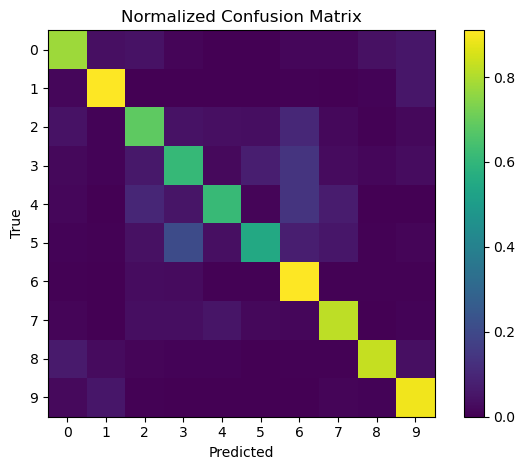

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7707652642816318..2.5101643742276685].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0047100606934776..2.2862699406490834].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9510349549389558..1.7642432944025097].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3938068393887812..2.1186529924971222].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9169517296237433..1.7454370092942304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8947292936556666..1.4191513618214813].
Clipping input data to

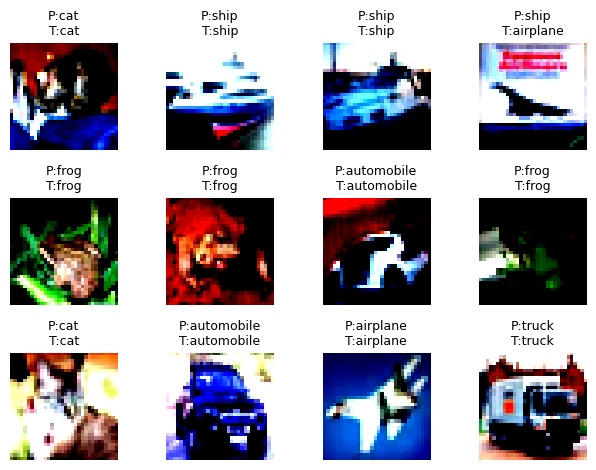

In [9]:
# ------- Plot 1: Training/validation curves --------
# why: understand optimization dynamics and potential over/under-fitting

# Extract history safely (works even if EarlyStopping cut early)
hist = history.history                                   # what: dict of lists: loss/acc across epochs
epochs_ran = range(1, len(hist["loss"]) + 1)             # what: x-axis for plots

# Create accuracy plot
plt.figure()                                             # what: one figure for one chart (policy)
plt.plot(epochs_ran, hist["accuracy"], label="train_acc")        # what: training accuracy curve
plt.plot(epochs_ran, hist["val_accuracy"], label="val_acc")      # what: validation accuracy curve
plt.xlabel("Epoch")                                      # why: axis title
plt.ylabel("Accuracy")                                   # why: axis title
plt.title("Accuracy vs Epochs")                          # why: chart title for clarity
plt.legend()                                             # why: distinguish curves
plt.grid(True)                                           # why: improve readability
plt.show()                                               # why: render figure

# Create loss plot
plt.figure()                                             # new figure (no subplots per policy)
plt.plot(epochs_ran, hist["loss"], label="train_loss")           # training loss
plt.plot(epochs_ran, hist["val_loss"], label="val_loss")         # validation loss
plt.xlabel("Epoch")                                      # label x
plt.ylabel("Loss")                                       # label y
plt.title("Loss vs Epochs")                              # title
plt.legend()                                             # legend
plt.grid(True)                                           # grid
plt.show()                                               # render

# ------- Plot 2: Confusion matrix --------
# why: see class-wise performance and failure modes

# Collect predictions and true labels from ds_test
y_true = []
y_pred = []
for xb, yb in ds_test:                                   # what: iterate over test batches
    probs = model.predict(xb, verbose=0)                 # what: get predicted probabilities
    y_pred.append(np.argmax(probs, axis=1))              # why: convert to class ids
    y_true.append(np.argmax(yb.numpy(), axis=1))         # why: one-hot -> class ids
y_true = np.concatenate(y_true)                          # stack into single arrays
y_pred = np.concatenate(y_pred)                          # stack into single arrays

# Compute confusion matrix with TF (avoid extra deps)
cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=NUM_CLASSES).numpy()  # what: counts per (true,pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)                                     # why: normalize rows to compare rates

# Plot confusion matrix (normalized)
plt.figure()                                             # one figure
plt.imshow(cm_norm, interpolation="nearest")             # what: heatmap; default colormap
plt.title("Normalized Confusion Matrix")                 # title
plt.xlabel("Predicted")                                   # label
plt.ylabel("True")                                        # label
plt.colorbar()                                            # legend for intensities
plt.xticks(ticks=np.arange(NUM_CLASSES))                 # tick marks
plt.yticks(ticks=np.arange(NUM_CLASSES))                 # tick marks
plt.tight_layout()                                        # layout
plt.show()                                                # render

# ------- Plot 3: Sample predictions grid --------
# why: qualitative sense of success/failure; show images and predicted vs true labels

# CIFAR-10 label names for readability
CIFAR10_LABELS = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]  # what: human names

# Pull a small batch from test set
xb_sample, yb_sample = next(iter(ds_test))               # what: one batch
probs = model.predict(xb_sample, verbose=0)              # what: probabilities
preds = np.argmax(probs, axis=1)                         # what: predicted class ids
truth = np.argmax(yb_sample.numpy(), axis=1)             # what: true class ids

# Plot first 12 images with labels
plt.figure()                                             # new figure
for i in range(12):                                      # limit grid size to keep readable
    plt.subplot(3, 4, i + 1)                             # 3 rows x 4 cols grid
    plt.imshow(xb_sample[i].numpy())                     # show RGB image
    title = f"P:{CIFAR10_LABELS[preds[i]]}\nT:{CIFAR10_LABELS[truth[i]]}"  # title with predicted/true
    plt.title(title, fontsize=9)                         # set title
    plt.axis("off")                                      # hide axes for clarity
plt.tight_layout()                                       # tight layout
plt.show()                                               # render